## Step 1: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Better visuals
sns.set(style="whitegrid")

## Step 2: Load Dataset

In [2]:
df = pd.read_csv("contextual_emotion_dataset.csv")

# Preview
df.head()

,previous_text,current_text,emotion,context_type
0,tonight in party w/ my girls (minus vita),@BBKwieen all of em! Hahahahaha sry,fun,same_emotion
1,HAPPY MOTHER'S DAY!!!!! | @tommcfly can't you ...,Why do people have 2 be so deceitful and unrea...,love,window_3
2,"@ProudKiwi missed you by 10 min, haha. went to...","So I played this game , yeahhhhh I lost I'm i...",worry,same_emotion
3,Download movie Notorious http://tinyurl.com/d...,"Goodmorning twitter, oh my gosh, i woke up soo...",neutral,same_emotion
4,@CreationsWHeart Ive been wanting 2 but will b...,Okay I lied! I meant this time next week! That...,sadness,same_emotion


## Step 3: Basic Info

In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)

print("\nContext Types:")
print(df['context_type'].unique())

print("\nEmotions:")
print(df['emotion'].unique())

Shape: (69375, 4)

Columns: Index(['previous_text', 'current_text', 'emotion', 'context_type'], dtype='object')

Context Types:
['same_emotion' 'window_3' 'emotion_shift']

Emotions:
['fun' 'love' 'worry' 'neutral' 'sadness' 'hate' 'happiness' 'empty'
 'surprise' 'relief' 'anger' 'enthusiasm' 'boredom']


## 1. Plot: Context Type Distribution

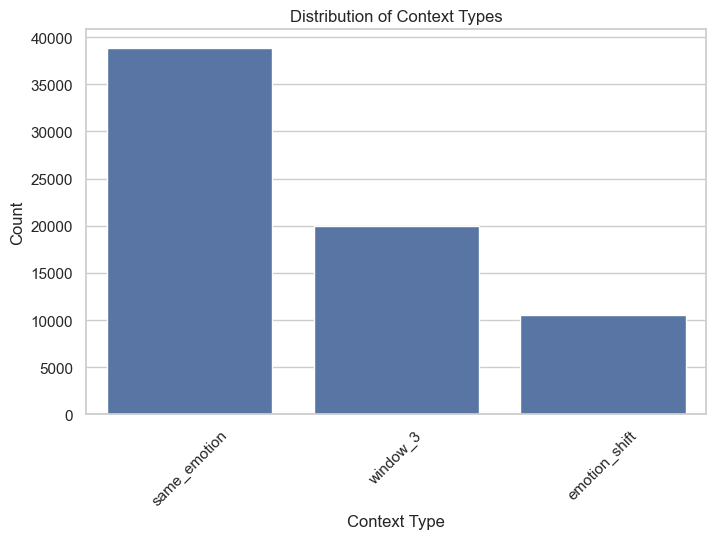

In [4]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='context_type', order=df['context_type'].value_counts().index)

plt.title("Distribution of Context Types")
plt.xlabel("Context Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## 2. Plot: Emotion Distribution

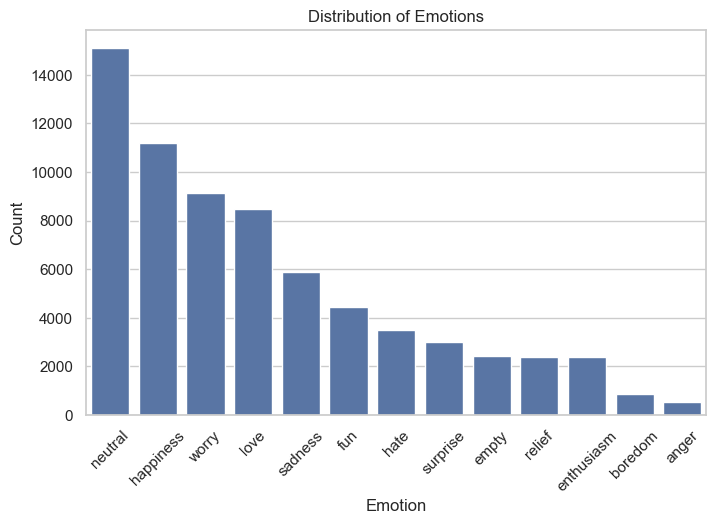

In [5]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='emotion', order=df['emotion'].value_counts().index)

plt.title("Distribution of Emotions")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## 3. Plot: Context Type vs Emotion (Combined)

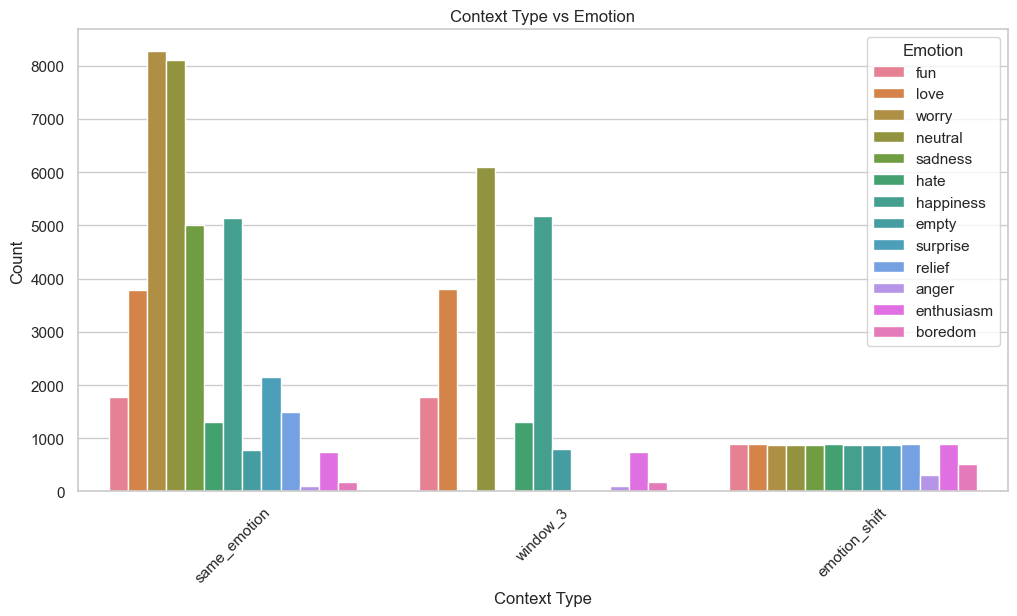

In [6]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='context_type', hue='emotion')

plt.title("Context Type vs Emotion")
plt.xlabel("Context Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Emotion")
plt.show()

## 4. Heatmap (Advanced & BEST 🔥)

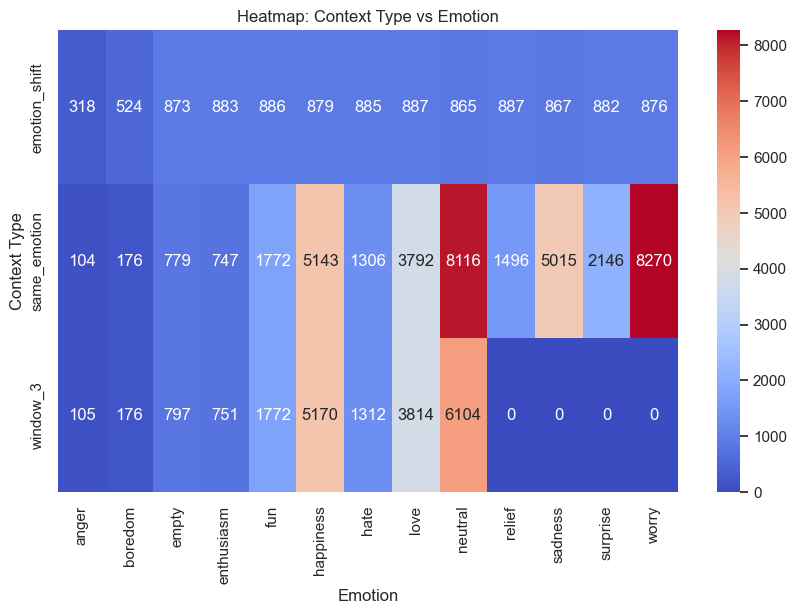

In [7]:
cross_tab = pd.crosstab(df['context_type'], df['emotion'])

plt.figure(figsize=(10,6))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='coolwarm')

plt.title("Heatmap: Context Type vs Emotion")
plt.xlabel("Emotion")
plt.ylabel("Context Type")
plt.show()

## 5. Percentage Plot 

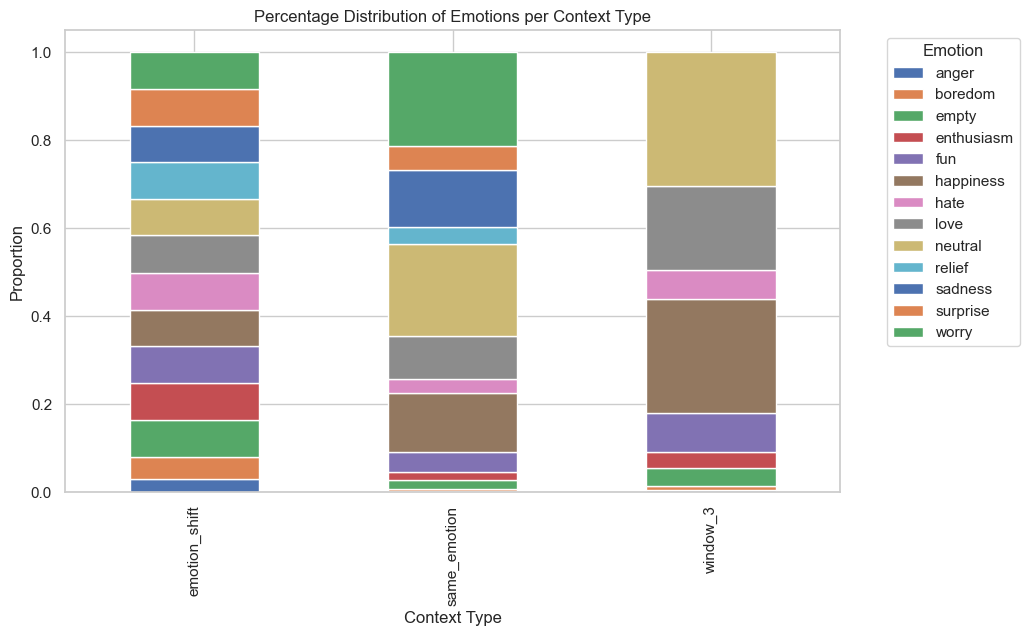

In [8]:
cross_tab_pct = cross_tab.div(cross_tab.sum(axis=1), axis=0)

cross_tab_pct.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title("Percentage Distribution of Emotions per Context Type")
plt.xlabel("Context Type")
plt.ylabel("Proportion")
plt.legend(title="Emotion", bbox_to_anchor=(1.05, 1))
plt.show()

## Code: Split Dataset by context_type
## Step 1: Create Separate DataFrames

In [9]:
df_same = df[df['context_type'] == 'same_emotion']
df_window = df[df['context_type'] == 'window_3']
df_shift = df[df['context_type'] == 'emotion_shift']

## Step 2: Check Sizes

In [10]:
print("Same Emotion:", df_same.shape)
print("Window_3:", df_window.shape)
print("Emotion Shift:", df_shift.shape)

Same Emotion: (38862, 4)
Window_3: (20001, 4)
Emotion Shift: (10512, 4)


## Save Each Dataset

In [12]:
df_same.to_csv("same_emotion.csv", index=False)
df_window.to_csv("window_3.csv", index=False)
df_shift.to_csv("emotion_shift.csv", index=False)